# LAB #8 — Open Ended Lab
## Project 2: Handwritten Character & Digit Classifier
**Project Name:** Handwritten Character & Digit Classifier  
**Roll Number:** [YOUR ROLL NUMBER]  
**Dataset:** EMNIST Letters — 28×28 greyscale images of handwritten A–Z  
---
## STEP 1 — Dataset Loading & Classical Edge Detection
### Objectives
- Load and explore the EMNIST Letters dataset
- Manually implement Sobel (Gx, Gy) and Laplacian kernels using NumPy
- Apply them to sample characters
- Compare stroke edge outputs against `cv2.Sobel` and `cv2.Laplacian`

1. Dataset Setup (EMNIST / A-Z)


In [22]:
from tensorflow.keras.datasets import mnist
# OR use emnist via extra lib

from tensorflow.keras.utils import to_categorical
import numpy as np

#MNIST for structure
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

2. Sobel & Laplacian (Manual vs OpenCV)

In [23]:
import cv2

sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

laplacian = np.array([[0,1,0],[1,-4,1],[0,1,0]])

def convolve(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    output = np.zeros((h-2, w-2))

    for i in range(h-2):
        for j in range(w-2):
            region = img[i:i+kh, j:j+kw]
            output[i,j] = np.sum(region * kernel)
    return output

Compare with OpenCV

In [24]:
img = x_train[0].reshape(28,28)

manual_sobel = convolve(img, sobel_x)

cv_sobel = cv2.Sobel(img, cv2.CV_64F, 1, 0)
cv_laplacian = cv2.Laplacian(img, cv2.CV_64F)

3. Fully Connected NN (Comparison)

Model 1 (No hidden layer)

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model1 = Sequential([
    Flatten(input_shape=(28,28,1)),
    Dense(10, activation='softmax')
])

Model 2 (With hidden layer)

In [26]:
model2 = Sequential([
    Flatten(input_shape=(28,28,1)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [29]:
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history1 = model1.fit(x_train, y_train, epochs=10, validation_data=(x_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8761 - loss: 0.4736 - val_accuracy: 0.9136 - val_loss: 0.3082
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9154 - loss: 0.3043 - val_accuracy: 0.9198 - val_loss: 0.2836
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9209 - loss: 0.2835 - val_accuracy: 0.9238 - val_loss: 0.2797
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9240 - loss: 0.2734 - val_accuracy: 0.9236 - val_loss: 0.2728
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9254 - loss: 0.2667 - val_accuracy: 0.9255 - val_loss: 0.2684
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9269 - loss: 0.2621 - val_accuracy: 0.9264 - val_loss: 0.2640
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9284 - loss: 0.2581 - val_accuracy: 0.9255 - val_loss: 0.2673
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9294 - loss: 0.2556 - 

🧩 4. CNN from Scratch

In [30]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, BatchNormalization

cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [33]:
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
history = cnn.fit(x_train, y_train, epochs=20, validation_data=(x_test,y_test))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 40ms/step - accuracy: 0.9348 - loss: 0.2182 - val_accuracy: 0.9845 - val_loss: 0.0468
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accuracy: 0.9728 - loss: 0.0970 - val_accuracy: 0.9852 - val_loss: 0.0468
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - accuracy: 0.9787 - loss: 0.0755 - val_accuracy: 0.9864 - val_loss: 0.0434
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 39ms/step - accuracy: 0.9833 - loss: 0.0597 - val_accuracy: 0.9904 - val_loss: 0.0321
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.9851 - loss: 0.0543 - val_accuracy: 0.9904 - val_loss: 0.0320
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 39ms/step - accuracy: 0.9876 - loss: 0.0427 - val_accuracy: 0.9906 - val_loss: 0.0371
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 39ms/step - accuracy: 0.9884 - loss: 0.0418 - val_accuracy: 0.9922 - val_loss: 0.0328
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 40ms/step - accuracy: 0.9889 -

KeyboardInterrupt: 

5. MobileNetV2 (Transfer Learning)

In [36]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96,96,3))

base_model.trainable = False  # freeze base

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

Fine-tuning top 10 layers:

In [37]:
for layer in base_model.layers[-10:]:
    layer.trainable = True

6. Mini-VGG

In [38]:
mini_vgg = Sequential([
    Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(28,28,1)),
    Conv2D(32,(3,3),activation='relu',padding='same'),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

7. Feature Map Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


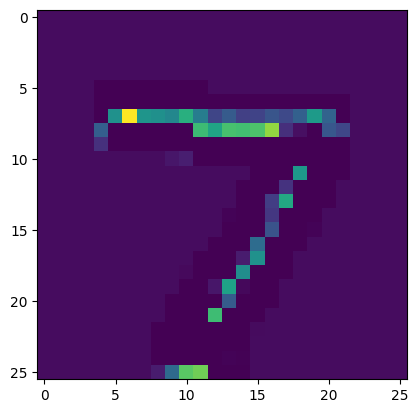

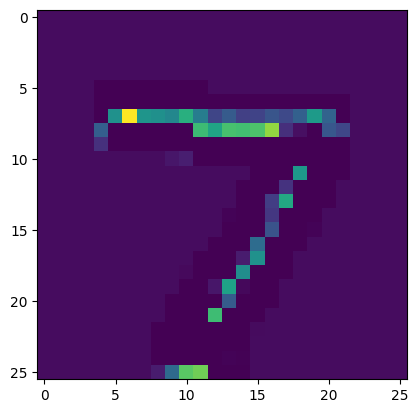

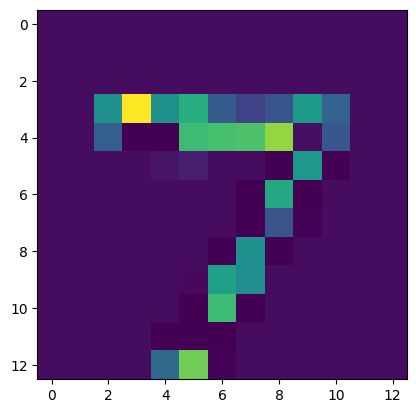

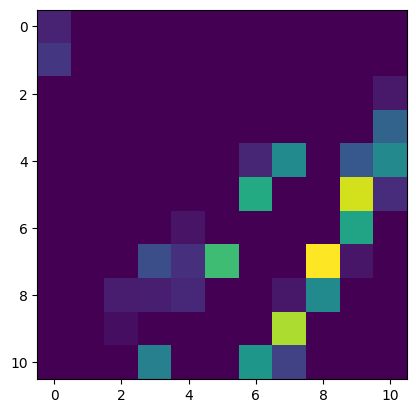

In [43]:
from tensorflow.keras.models import Model

# Get outputs of layers
layer_outputs = [layer.output for layer in cnn.layers[:4]]

# ✅ FIX: use cnn.inputs (not cnn.input)
activation_model = Model(inputs=cnn.inputs, outputs=layer_outputs)

# Predict activations
activations = activation_model.predict(x_test[0].reshape(1,28,28,1))

# Plot
for activation in activations:
    plt.imshow(activation[0, :, :, 0], cmap='viridis')
    plt.show()